In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

# Import Model
from models.AutoEncoder.AutoEncoder_d import AE

# Import utils
from utils.train_val_ae_utils import train_and_evaluate_ae
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_ae_utils import load_best_model_ae
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


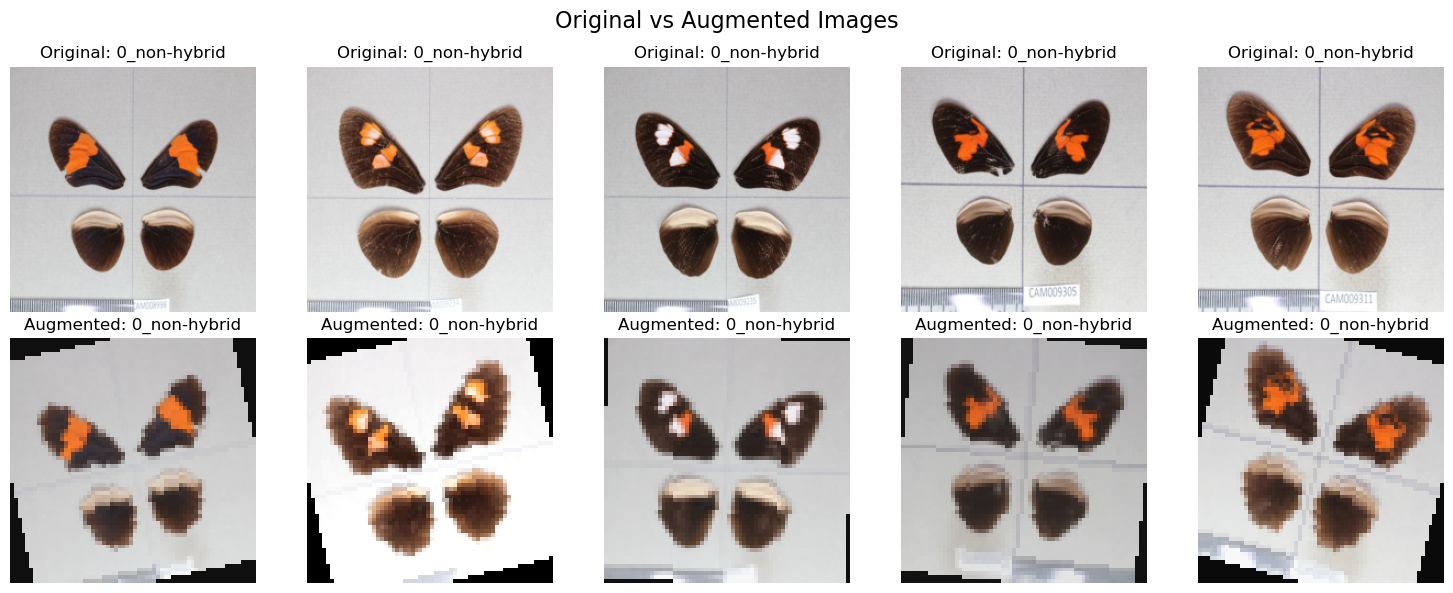

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [5]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
batch_size_values = [16, 32, 64, 128]

model_ae_d_dict = {}
optimizer_d_dict = {}
results_d_dict = {}
best_d_dict = {}
best_f2_d_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_batch_size_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_batch_size = 16

best_f2 = float("-inf")

# prepare non hybrid indices for training the autoencoder on only normal samples
non_hybrid_idx = train_dataset_aug.class_to_idx["0_non-hybrid"]
normal_indices = [i for i, y in enumerate(train_dataset_aug.targets) if y == non_hybrid_idx]

# hyperparameter tuning for learning rate
for learning_rate in learning_rate_values:
    model_ae_d_dict[f"model_ae_d{count}"] = AE().to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(
        model_ae_d_dict[f"model_ae_d{count}"].parameters(),
        lr=learning_rate,
        weight_decay=best_weight_decay,
    )
    criterion = nn.MSELoss()

    train_loader_ae = DataLoader(Subset(train_dataset_aug, normal_indices), batch_size=best_batch_size, shuffle=True, num_workers=0)
    val_loader_ae = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0)

    ckpt_file = f"../../saved_models/ae/ae_d/ae_model_d{count}_log.pkl"
    print(f"\nTraining AutoEncoder Model D{count} with learning rate {learning_rate}")
    train_and_evaluate_ae(
        model=model_ae_d_dict[f"model_ae_d{count}"],
        train_loader=train_loader_ae,
        val_loader=val_loader_ae,
        optimizer=optimizer_d_dict[f"optimizer_d{count}"],
        criterion=criterion,
        num_epochs=30,
        ckpt_file=ckpt_file,
        device=device,
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
    )

    results_d_dict[f"results_d{count}"] = results_from_ckpt(model_ae_d_dict[f"model_ae_d{count}"], ckpt_file=ckpt_file)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_ae_d_dict[f"model_ae_d{count}"], ckpt_file=ckpt_file)
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size

    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# hyperparameter tuning for weight decay
for weight_decay in weight_decay_values[1:]:
    model_ae_d_dict[f"model_ae_d{count}"] = AE().to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(
        model_ae_d_dict[f"model_ae_d{count}"].parameters(),
        lr=best_learning_rate,
        weight_decay=weight_decay,
    )
    criterion = nn.MSELoss()

    train_loader_ae = DataLoader(Subset(train_dataset_aug, normal_indices), batch_size=best_batch_size, shuffle=True, num_workers=0)
    val_loader_ae = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0)

    ckpt_file = f"../../saved_models/ae/ae_d/ae_model_d{count}_log.pkl"
    print(f"\nTraining AutoEncoder Model D{count} with weight decay {weight_decay}")
    train_and_evaluate_ae(
        model=model_ae_d_dict[f"model_ae_d{count}"],
        train_loader=train_loader_ae,
        val_loader=val_loader_ae,
        optimizer=optimizer_d_dict[f"optimizer_d{count}"],
        criterion=criterion,
        num_epochs=30,
        ckpt_file=ckpt_file,
        device=device,
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
    )

    results_d_dict[f"results_d{count}"] = results_from_ckpt(model_ae_d_dict[f"model_ae_d{count}"], ckpt_file=ckpt_file)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_ae_d_dict[f"model_ae_d{count}"], ckpt_file=ckpt_file)
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = weight_decay
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size

    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# hyperparameter tuning for batch size
for batch_size in batch_size_values[1:]:
    model_ae_d_dict[f"model_ae_d{count}"] = AE().to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(
        model_ae_d_dict[f"model_ae_d{count}"].parameters(),
        lr=best_learning_rate,
        weight_decay=best_weight_decay,
    )
    criterion = nn.MSELoss()

    train_loader_ae = DataLoader(Subset(train_dataset_aug, normal_indices), batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader_ae = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    ckpt_file = f"../../saved_models/ae/ae_d/ae_model_d{count}_log.pkl"
    print(f"\nTraining AutoEncoder Model D{count} with batch size {batch_size}")
    train_and_evaluate_ae(
        model=model_ae_d_dict[f"model_ae_d{count}"],
        train_loader=train_loader_ae,
        val_loader=val_loader_ae,
        optimizer=optimizer_d_dict[f"optimizer_d{count}"],
        criterion=criterion,
        num_epochs=30,
        ckpt_file=ckpt_file,
        device=device,
        patience=6,
        min_delta=1e-3,
        restore_best_weights=True,
    )

    results_d_dict[f"results_d{count}"] = results_from_ckpt(model_ae_d_dict[f"model_ae_d{count}"], ckpt_file=ckpt_file)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_ae_d_dict[f"model_ae_d{count}"], ckpt_file=ckpt_file)
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_batch_size_dict[f"best_batch_size_d{count}"] = batch_size

    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]


Training AutoEncoder Model D1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.589789
Epoch [5/30], Train Loss: 0.0292, Val Loss: 0.0235, Train F1-Macro: 0.0153, Val F1-Macro: 0.2204, Train F1-Per-Class: [0.03066667 0.        ], Val F1-Per-Class: [0.14105794 0.29979467], Train F2-Macro: 0.0097, Val F2-Macro: 0.3050, Train F2-Per-Class: [0.01938965 0.        ], Val F2-Per-Class: [0.0930851  0.51699716], No improvement: 4/6

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.589789)
Selected epoch: 1
Best val F2(class 0): 0.4872107207775116
Best val F2(class 1): 0.5897887349128723

Training AutoEncoder Model D2 with learning rate 0.005
  [Epoch 1] Improvement! New best score: 0.532646
  [Epoch 2] Improvement! New best score: 0.608856
  [Epoch 3] Improvement! New best score: 0.670611
Epoch [5/30], Train Loss: 0.0262, Val Loss: 0.0267, Train F1-Macro: 0.2135, Val F1-Macro: 0.5534, Train F1-Per-Class: [0.42705005 0.   

In [7]:
# Restore best hyperparameters for model_d
best_learning_rate_dict = {'best_learning_rate_d1': 0.01, 'best_learning_rate_d2': 0.005, 'best_learning_rate_d3': 0.001, 'best_learning_rate_d4': 0.0001, 'best_learning_rate_d5': 0.001, 'best_learning_rate_d6': 0.001, 'best_learning_rate_d7': 0.001, 'best_learning_rate_d8': 0.001, 'best_learning_rate_d9': 0.001, 'best_learning_rate_d10': 0.001}
best_weight_decay_dict = {'best_weight_decay_d1': 0.001, 'best_weight_decay_d2': 0.001, 'best_weight_decay_d3': 0.001, 'best_weight_decay_d4': 0.001, 'best_weight_decay_d5': 0.0001, 'best_weight_decay_d6': 1e-05, 'best_weight_decay_d7': 1e-06, 'best_weight_decay_d8': 0.001, 'best_weight_decay_d9': 0.001, 'best_weight_decay_d10': 0.001}
best_batch_size_dict = {'best_batch_size_d1': 16, 'best_batch_size_d2': 16, 'best_batch_size_d3': 16, 'best_batch_size_d4': 16, 'best_batch_size_d5': 16, 'best_batch_size_d6': 16, 'best_batch_size_d7': 16, 'best_batch_size_d8': 32, 'best_batch_size_d9': 64, 'best_batch_size_d10': 128}

# Initialize model_ae_d_dict with AE instances for each hyperparameter combination
model_ae_d_dict = {
    f"model_ae_d{i}": AE().to(device)
    for i in range(1, 11)
}

best_d_dict = {}
best_f2_d_dict = {}

In [8]:
for i in range(1, 6):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']}"
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_ae_d_dict[f"model_ae_d{i}"], ckpt_file=f"../../saved_models/ae/ae_d/ae_model_d{i}_log.pkl")

Model D1 | lr=0.01 | wd=0.001 | bs=16
Selected epoch: 1
Best val F2(class 0): 0.4872107207775116
Best val F2(class 1): 0.5897887349128723
Model D2 | lr=0.005 | wd=0.001 | bs=16
Selected epoch: 3
Best val F2(class 0): 0.651790976524353
Best val F2(class 1): 0.6706114411354065
Model D3 | lr=0.001 | wd=0.001 | bs=16
Selected epoch: 8
Best val F2(class 0): 0.7068366408348083
Best val F2(class 1): 0.692148745059967
Model D4 | lr=0.0001 | wd=0.001 | bs=16
Selected epoch: 2
Best val F2(class 0): 0.5411906242370605
Best val F2(class 1): 0.6032906770706177
Model D5 | lr=0.001 | wd=0.0001 | bs=16
Selected epoch: 2
Best val F2(class 0): 0.5915576815605164
Best val F2(class 1): 0.625


In [9]:
for i in range(6, 11):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']}"
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_ae_d_dict[f"model_ae_d{i}"], ckpt_file=f"../../saved_models/ae/ae_d/ae_model_d{i}_log.pkl")

Model D6 | lr=0.001 | wd=1e-05 | bs=16
Selected epoch: 1
Best val F2(class 0): 0.5986959338188171
Best val F2(class 1): 0.6118546724319458
Model D7 | lr=0.001 | wd=1e-06 | bs=16
Selected epoch: 4
Best val F2(class 0): 0.44027093052864075
Best val F2(class 1): 0.5802047848701477
Model D8 | lr=0.001 | wd=0.001 | bs=32
Selected epoch: 2
Best val F2(class 0): 0.8098194003105164
Best val F2(class 1): 0.7305936217308044
Model D9 | lr=0.001 | wd=0.001 | bs=64
Selected epoch: 12
Best val F2(class 0): 0.6213191747665405
Best val F2(class 1): 0.60546875
Model D10 | lr=0.001 | wd=0.001 | bs=128
Selected epoch: 10
Best val F2(class 0): 0.7118055820465088
Best val F2(class 1): 0.6950207352638245


In [10]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_d_dict, key=lambda k: float(best_f2_d_dict[k]))
best_i = int(best_f2_key.split("d")[-1])

model = model_ae_d_dict[f"model_ae_d{best_i}"]
best = best_d_dict[f"best_d{best_i}"]

print(
    f"Selected Best Model D{best_i} | "
    f"val_f2_class1={float(best_f2_d_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_d{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_d{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_d{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model_ae(
        best_model=model,
        best=best,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        device=device,
        batch_size=best_batch_size_dict[f'best_batch_size_d{best_i}'],
        num_workers=2,
        beta=2.0,
)

Selected Best Model D8 | val_f2_class1=0.730594 | lr=0.001 | wd=0.001 | bs=32
Test loss: 0.004127169715928602
Test F2 macro: 0.7243072986602783
Test F2 per class: [0.7753254 0.6732892]
Test F2 for class 1 (1_hybrid): 0.6732891798019409


{'threshold': 0.0042638076861765874,
 'val_f2': 0.7305936217308044,
 'test_loss': 0.004127169715928602,
 'test_f2_macro': 0.7243072986602783,
 'test_f2_per_class': array([0.7753254, 0.6732892], dtype=float32),
 'test_f2': 0.6732891798019409}

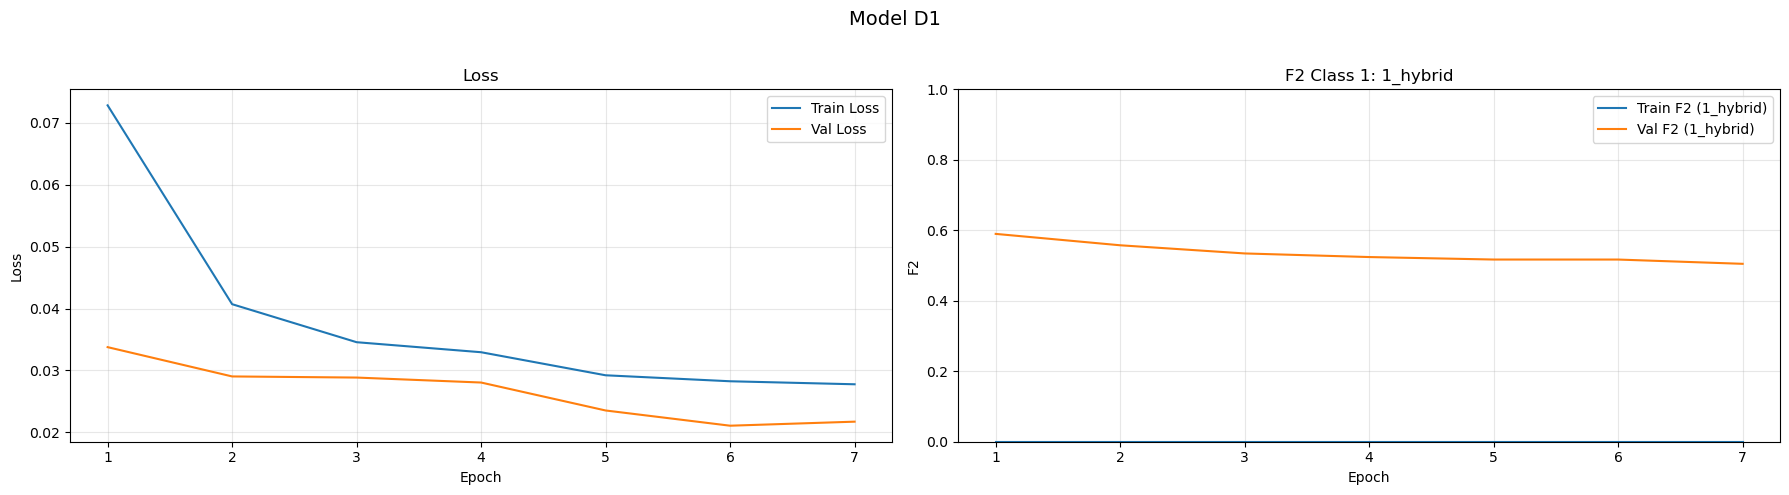

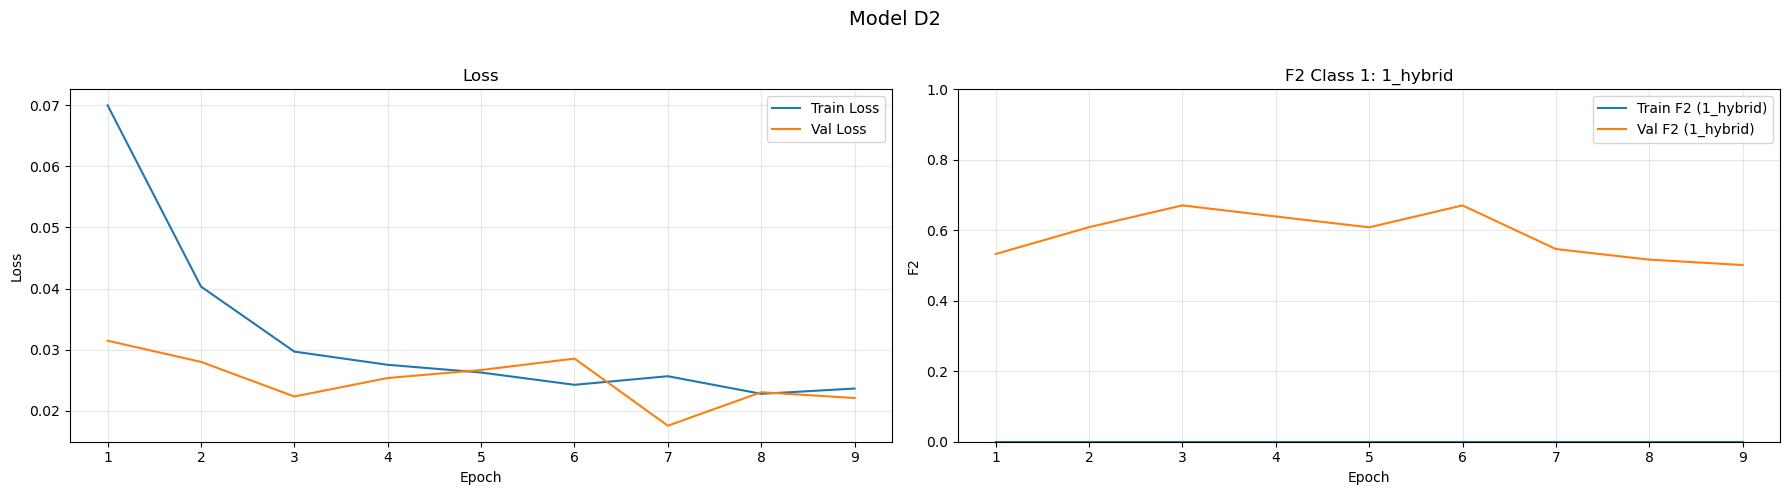

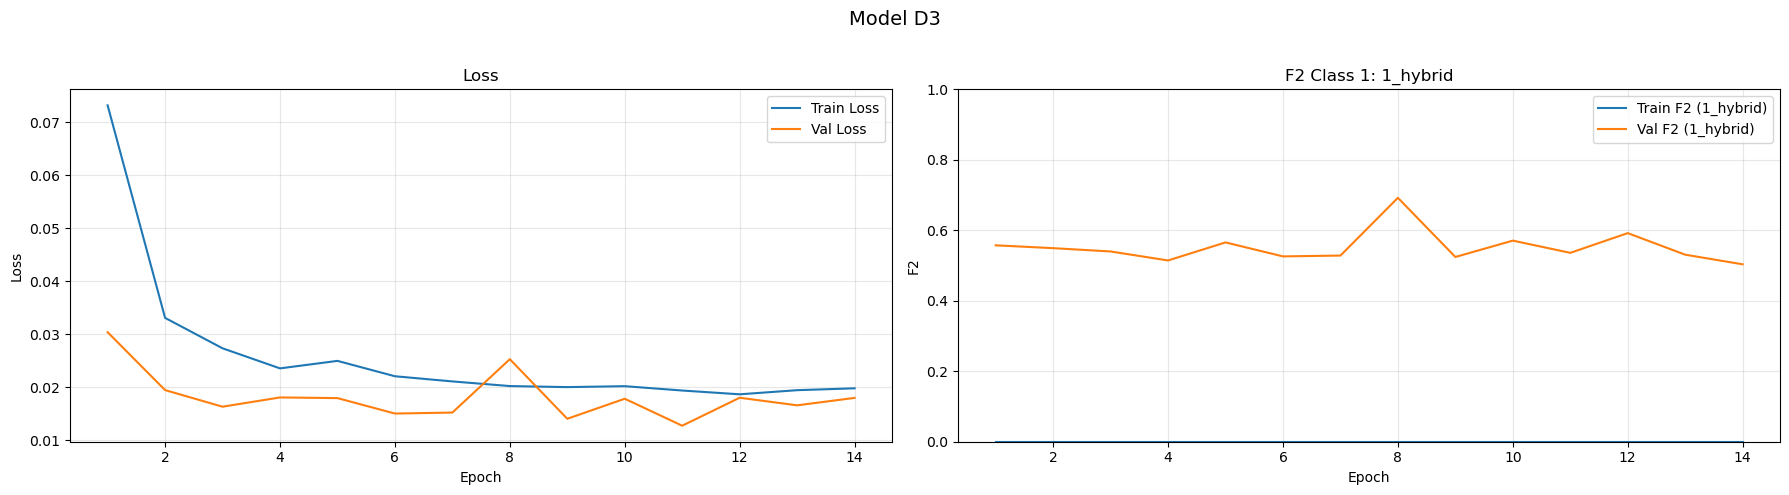

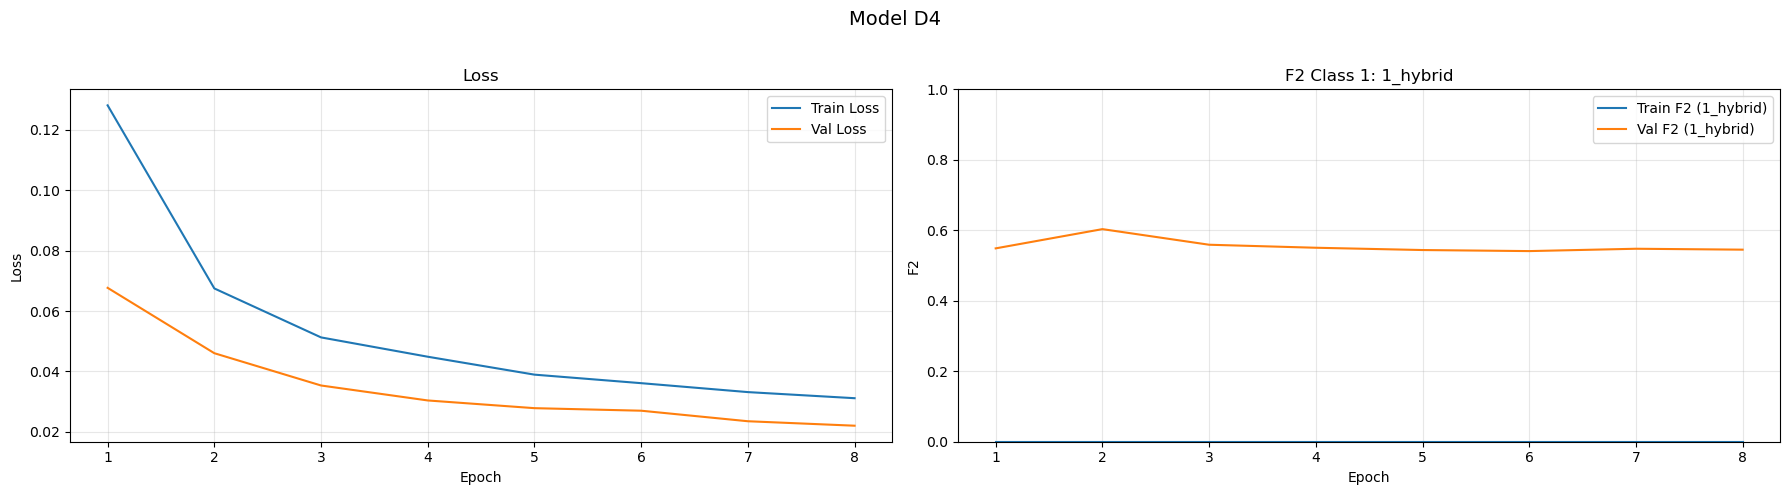

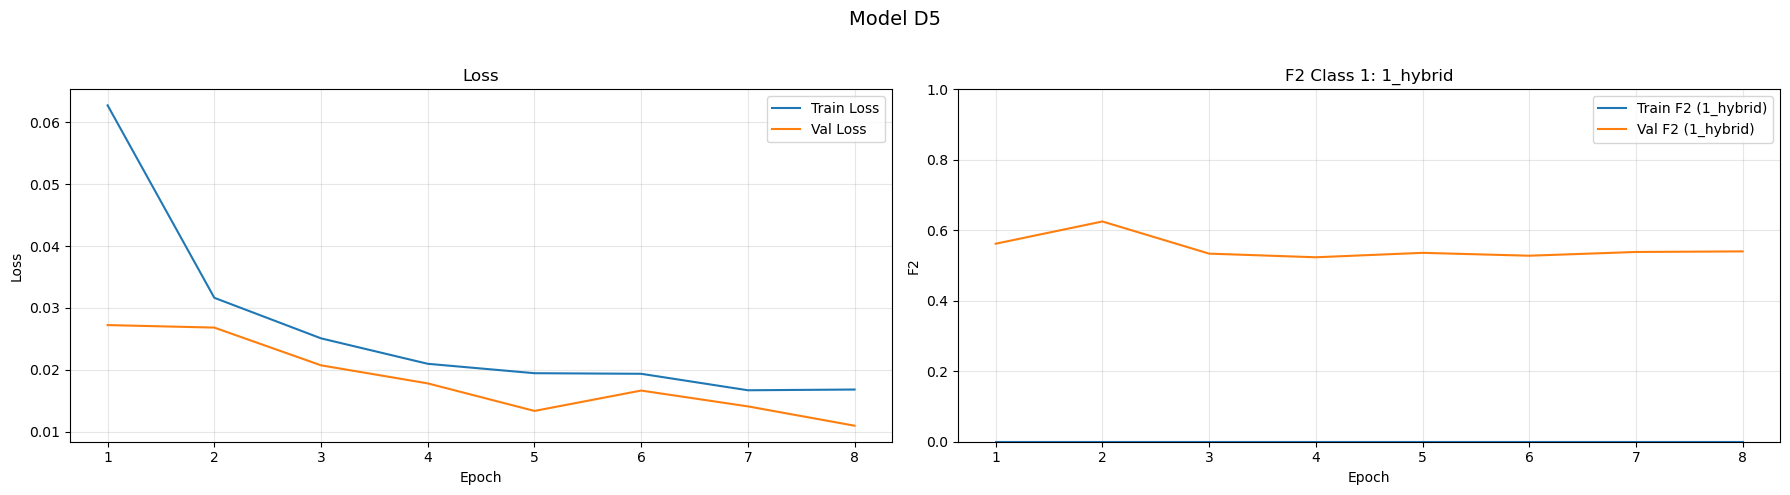

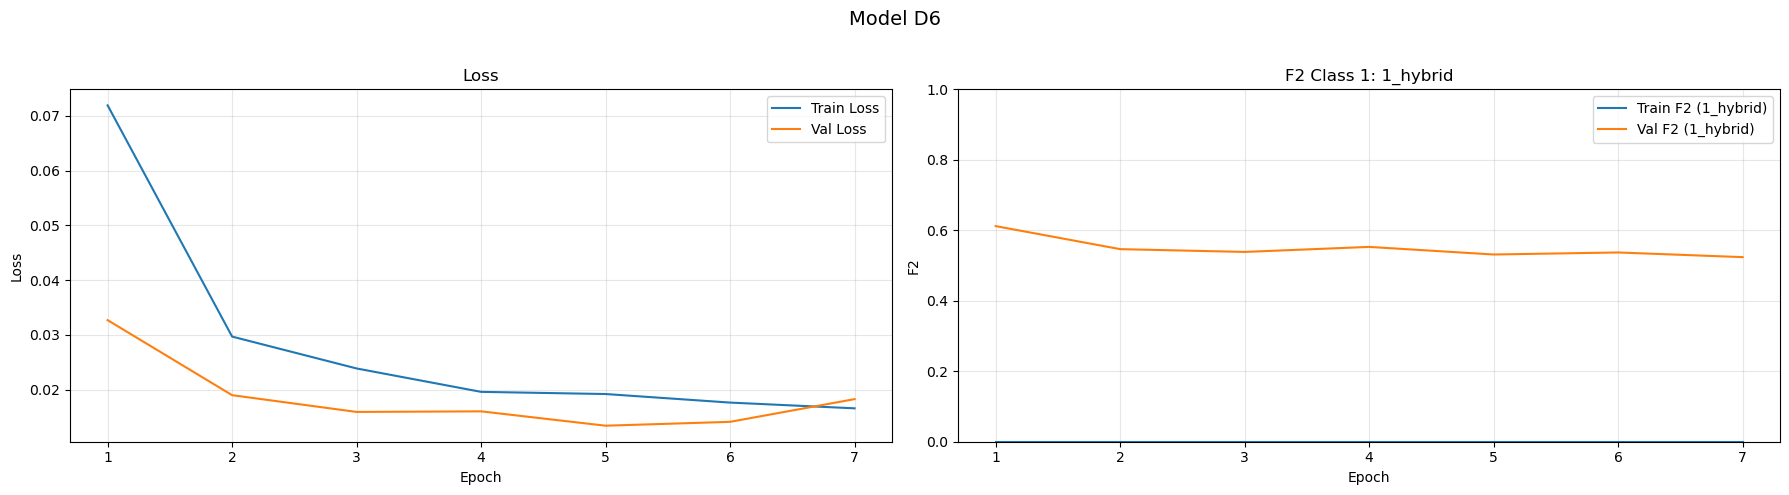

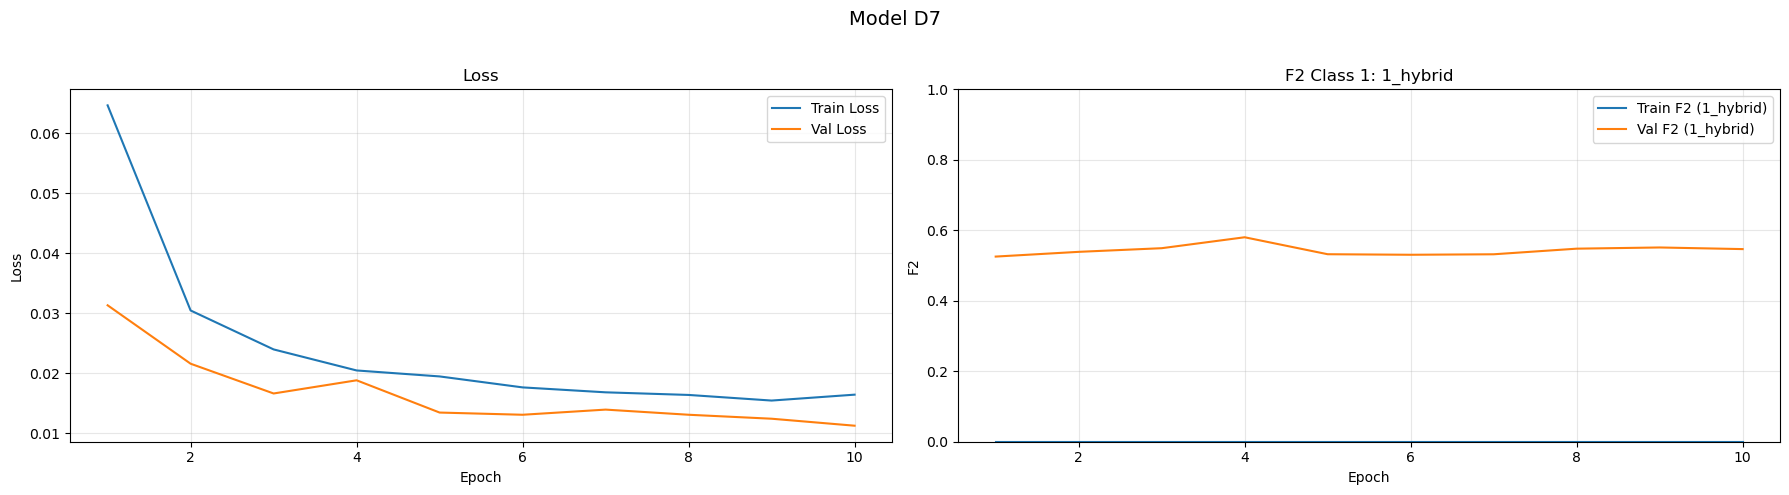

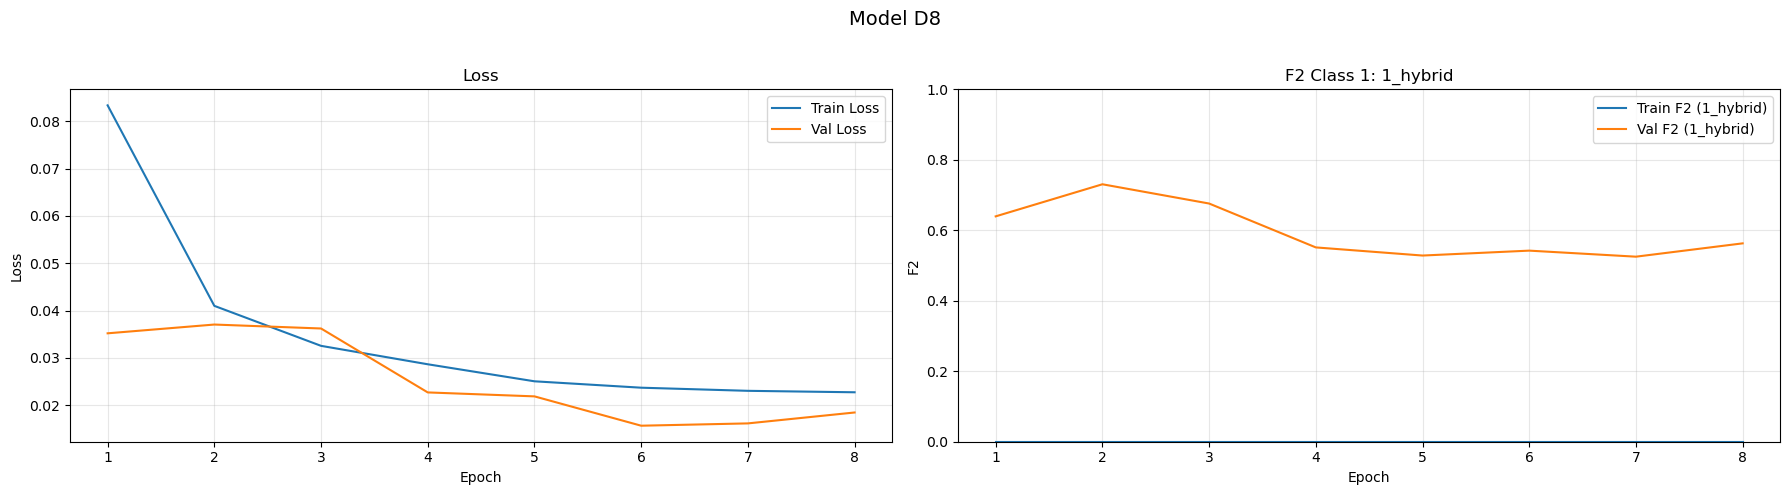

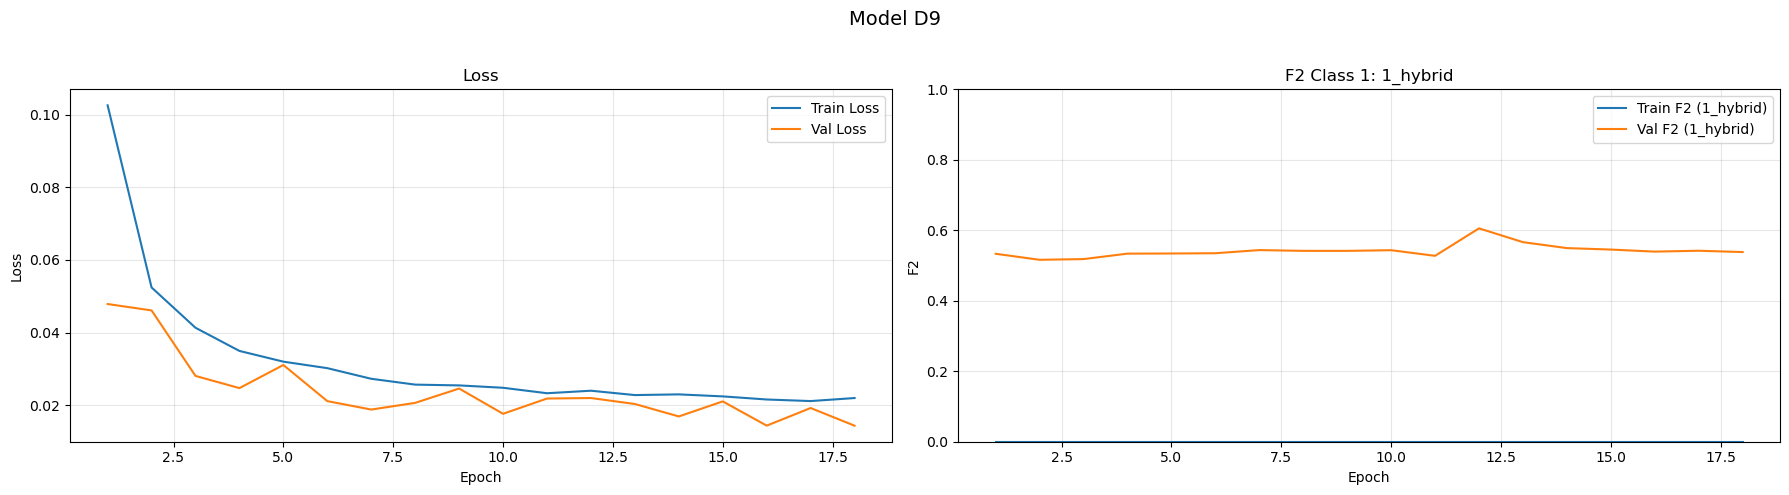

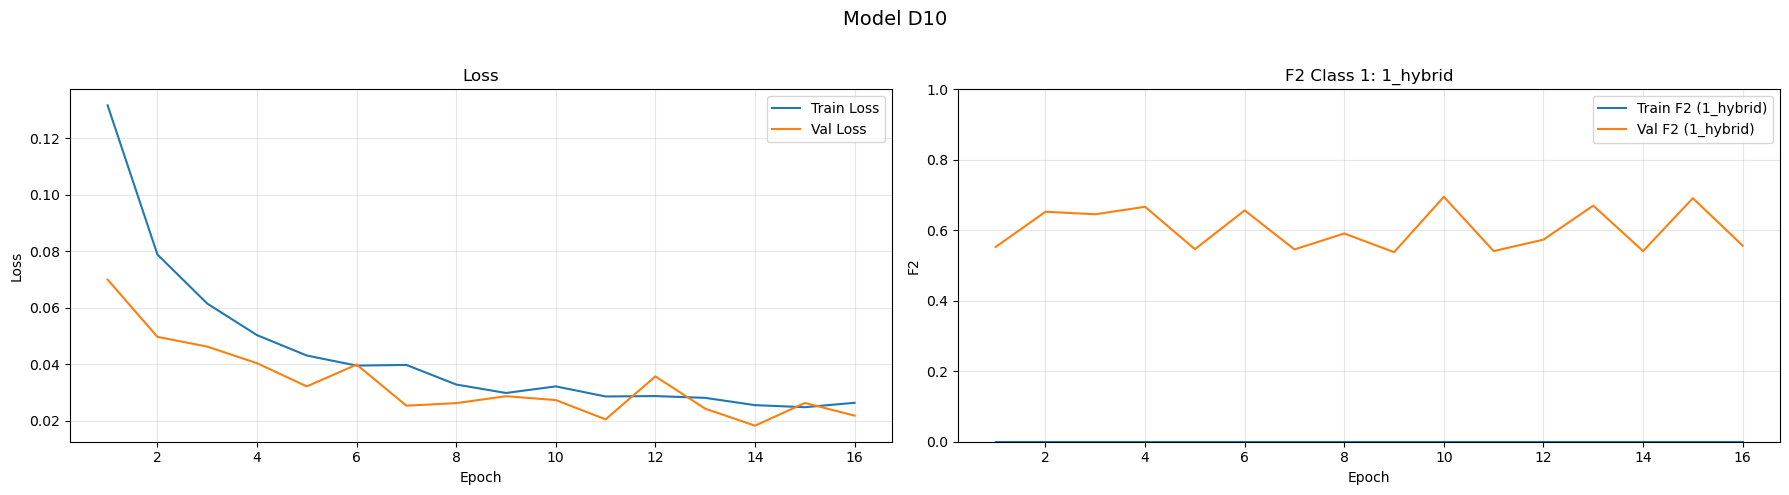

In [11]:
for i in range(1, 11):
    plot_training_curves(
        model_name=f"Model D{i}",
        results = results_from_ckpt(
            model=model_ae_d_dict[f"model_ae_d{i}"],
            ckpt_file=f"../../saved_models/ae/ae_d/ae_model_d{i}_log.pkl"
        ),
        class_idx=1,
        class_name="1_hybrid"
    )